In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

PyTorch version: 2.7.1
CUDA available: False
GPU: None


In [3]:
import os
import shutil
from icrawler.builtin import BingImageCrawler

DATASET_DIR = "my_heroes"

# Wipe and restart for the real scrape
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)
os.makedirs(DATASET_DIR)

# Hero name → folder name → 5 search queries
HEROES = {
    "iron_man": [
        "Iron Man movie",
        "Iron Man action scene",
        "Iron Man comic",
        "Iron Man illustration",
        "Tony Stark armor",
    ],
    "captain_america": [
        "Captain America movie",
        "Captain America action scene",
        "Captain America comic",
        "Captain America illustration",
        "Captain America shield",
    ],
    "thor": [
        "Thor movie",
        "Thor action scene",
        "Thor comic",
        "Thor illustration",
        "Thor Marvel hammer",
    ],
    "hulk": [
        "Hulk movie",
        "Hulk action scene",
        "Hulk comic",
        "Hulk illustration",
        "Incredible Hulk smash",
    ],
    "spider_man": [
        "Spider-Man movie",
        "Spider-Man action scene",
        "Spider-Man comic",
        "Spider-Man illustration",
        "Spider-Man swinging",
    ],
    "batman": [
        "Batman movie",
        "Batman action scene",
        "Batman comic",
        "Batman illustration",
        "Batman cape cowl",
    ],
    "superman": [
        "Superman movie",
        "Superman action scene",
        "Superman comic",
        "Superman illustration",
        "Superman flying",
    ],
    "wonder_woman": [
        "Wonder Woman movie",
        "Wonder Woman action scene",
        "Wonder Woman comic",
        "Wonder Woman illustration",
        "Wonder Woman lasso",
    ],
    "flash": [
        "The Flash superhero movie",
        "Flash superhero action scene",
        "Flash superhero comic",
        "Flash DC illustration",
        "Barry Allen Flash running",
    ],
    "aquaman": [
        "Aquaman movie",
        "Aquaman action scene",
        "Aquaman comic",
        "Aquaman illustration",
        "Aquaman trident",
    ],
}

IMAGES_PER_QUERY = 100  # 5 queries × 100 = ~500 raw per hero

for hero, queries in HEROES.items():
    print(f"\n=== Scraping {hero} ===")
    target_dir = os.path.join(DATASET_DIR, hero)
    os.makedirs(target_dir, exist_ok=True)
    
    for query in queries:
        crawler = BingImageCrawler(
            storage={"root_dir": target_dir},
            log_level=40,
        )
        try:
            crawler.crawl(
                keyword=query,
                max_num=IMAGES_PER_QUERY,
                file_idx_offset="auto",
                min_size=(150, 150),
            )
        except Exception as e:
            print(f"  '{query}' had an error: {e} — skipping")
            continue
        n = len(os.listdir(target_dir))
        print(f"  '{query}' done. Total in folder: {n}")

# Final summary
print("\n=== Scrape complete ===")
total = 0
for hero in HEROES:
    n = len(os.listdir(os.path.join(DATASET_DIR, hero)))
    total += n
    print(f"  {hero}: {n} images")
print(f"  TOTAL: {total} images")


=== Scraping iron_man ===


2026-05-06 20:20:38,200 - ERROR - downloader - Response status code 403, file https://w0.peakpx.com/wallpaper/820/48/HD-wallpaper-iron-man-suits-character-suit-tony-stark-movie-film-hero-iron-man-actor.jpg


  'Iron Man movie' done. Total in folder: 90


2026-05-06 20:20:55,455 - ERROR - downloader - Response status code 404, file https://i.ytimg.com/vi/tlBjaayhPKQ/hqdefault.jpg


  'Iron Man action scene' done. Total in folder: 177
  'Iron Man comic' done. Total in folder: 277


...

  'Aquaman comic' done. Total in folder: 236


2026-05-06 20:47:10,904 - ERROR - downloader - Response status code 401, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/2871eb7f-029e-4364-a581-49e7ef3e9647/dcvdq9j-78517afc-dac6-4d17-97e0-b6c1a58aba8c.jpg
2026-05-06 20:47:11,049 - ERROR - downloader - Response status code 403, file https://p4.wallpaperbetter.com/wallpaper/555/897/118/comics-aquaman-wallpaper-preview.jpg
2026-05-06 20:47:12,620 - ERROR - downloader - Response status code 401, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/7cf27439-2df2-4959-b380-d0d6804d3c7d/d2a84yw-650f07c0-671b-4fcf-ad24-83979ee42b10.jpg
2026-05-06 20:47:16,051 - ERROR - downloader - Response status code 403, file http://www.comicartcommunity.com/gallery/data/media/280/Aquaman_4.jpg
2026-05-06 20:47:28,871 - ERROR - downloader - Response status code 403, file http://www.comicartcommunity.com/gallery/data/media/242/Aquaman_0013.jpg
2026-05-06 20:47:28,980 - ERROR - downloader - Response status code 401, file https://ima

  'Aquaman illustration' done. Total in folder: 312


2026-05-06 20:48:01,108 - ERROR - downloader - Response status code 401, file https://images-wixmp-ed30a86b8c4ca887773594c2.wixmp.com/f/5f3953ab-158a-46cc-bf8a-966a665a5af2/ddjr5ws-a4486433-43f2-4ae5-bb04-48fe8d3fbc45.png/v1/fill/w_721,h_91,q_80,strp/atlanna_s_trident__aquaman__by_hybrid55555_ddjr5ws-fullview.jpg


  'Aquaman trident' done. Total in folder: 396

=== Scrape complete ===
  iron_man: 432 images
  captain_america: 345 images
  thor: 407 images
  hulk: 419 images
  spider_man: 397 images
  batman: 429 images
  superman: 384 images
  wonder_woman: 374 images
  flash: 364 images
  aquaman: 396 images
  TOTAL: 3947 images


In [4]:
import os
import hashlib
from PIL import Image

DATASET_DIR = "my_heroes"

removed_corrupt = 0
removed_duplicate = 0
kept = 0

for hero in os.listdir(DATASET_DIR):
    hero_dir = os.path.join(DATASET_DIR, hero)
    if not os.path.isdir(hero_dir):
        continue

    seen_hashes = set()  # per-hero, so identical images across heroes are kept
    
    for fname in sorted(os.listdir(hero_dir)):
        fpath = os.path.join(hero_dir, fname)

        # Step 1: try to open it. If PIL can't, it's corrupt.
        try:
            with Image.open(fpath) as img:
                img.verify()  # checks integrity without full decode
        except Exception:
            os.remove(fpath)
            removed_corrupt += 1
            continue

        # Step 2: hash file contents to catch byte-identical duplicates
        with open(fpath, "rb") as f:
            file_hash = hashlib.md5(f.read()).hexdigest()
        
        if file_hash in seen_hashes:
            os.remove(fpath)
            removed_duplicate += 1
        else:
            seen_hashes.add(file_hash)
            kept += 1

print(f"Removed {removed_corrupt} corrupt files")
print(f"Removed {removed_duplicate} exact duplicates")
print(f"Kept {kept} images")
print()
for hero in sorted(os.listdir(DATASET_DIR)):
    hero_dir = os.path.join(DATASET_DIR, hero)
    if os.path.isdir(hero_dir):
        print(f"  {hero}: {len(os.listdir(hero_dir))} images")

Removed 0 corrupt files
Removed 138 exact duplicates
Kept 3809 images

  aquaman: 382 images
  batman: 420 images
  captain_america: 337 images
  flash: 337 images
  hulk: 395 images
  iron_man: 424 images
  spider_man: 389 images
  superman: 367 images
  thor: 389 images
  wonder_woman: 369 images


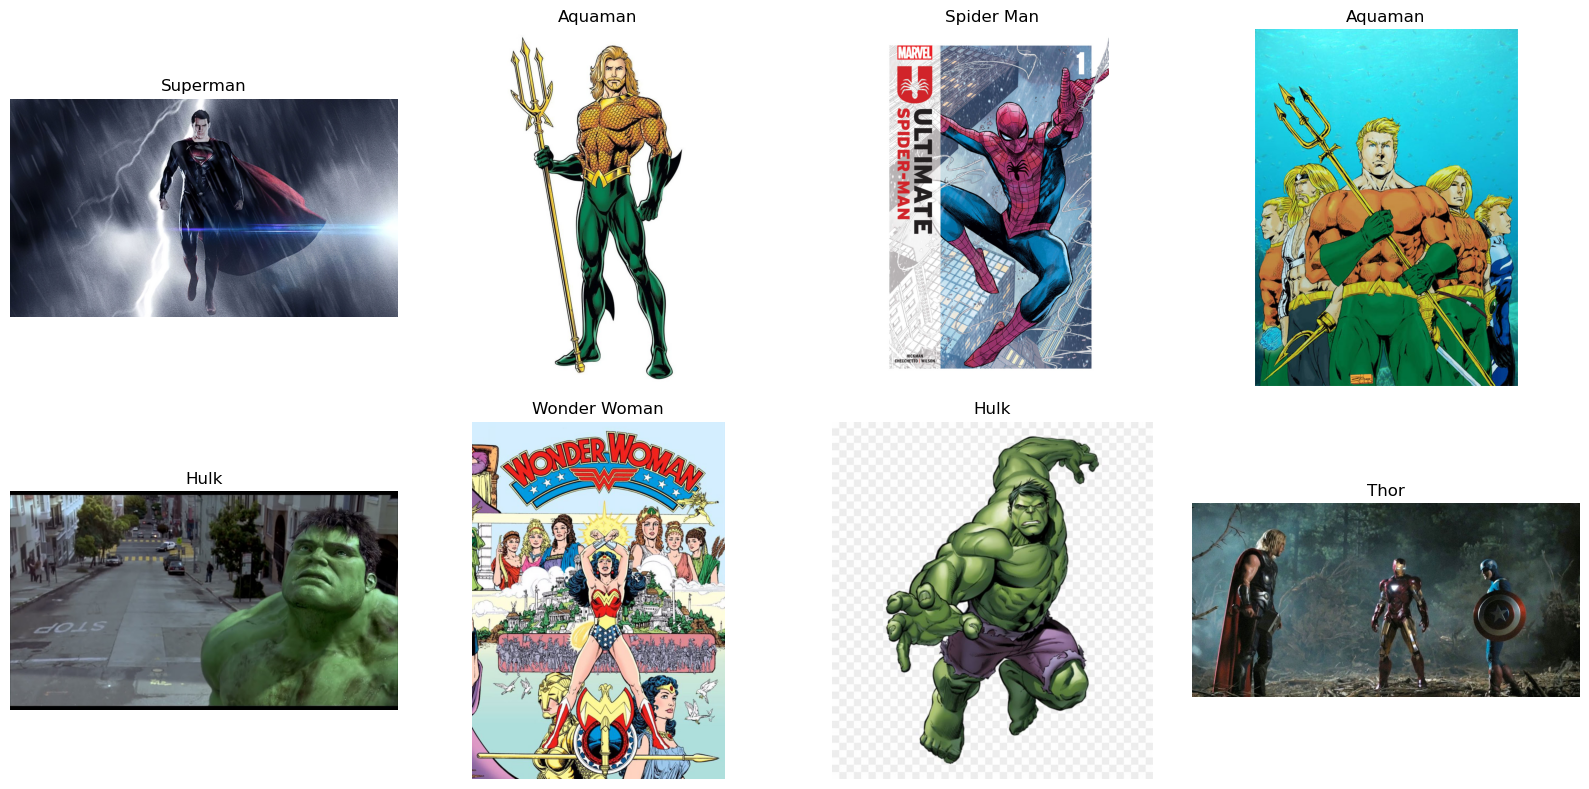

In [60]:
import os, random
import matplotlib.pyplot as plt
from PIL import Image

DATASET_DIR = "my_heroes"

# Collect (image_path, label) for every image in the dataset
all_images = [
    (os.path.join(DATASET_DIR, hero, fname), hero)
    for hero in os.listdir(DATASET_DIR)
    if os.path.isdir(os.path.join(DATASET_DIR, hero))
    for fname in os.listdir(os.path.join(DATASET_DIR, hero))
]

sample = random.sample(all_images, 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (path, label) in zip(axes.flat, sample):
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.set_title(label.replace("_", " ").title(), fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [61]:
import os, shutil, random

SRC_DIR   = "my_heroes"
SPLIT_DIR = "my_heroes_split"
TRAIN_RATIO = 0.8

random.seed(42)

for hero in os.listdir(SRC_DIR):
    hero_dir = os.path.join(SRC_DIR, hero)
    if not os.path.isdir(hero_dir):
        continue

    images = os.listdir(hero_dir)
    random.shuffle(images)

    n_train = int(len(images) * TRAIN_RATIO)
    splits = {"train": images[:n_train], "test": images[n_train:]}

    for split, files in splits.items():
        dest = os.path.join(SPLIT_DIR, split, hero)
        os.makedirs(dest, exist_ok=True)
        for fname in files:
            shutil.copy2(os.path.join(hero_dir, fname), os.path.join(dest, fname))

# Summary
print(f"{'Hero':<20} {'Train':>6} {'Test':>6}")
print("-" * 34)
for hero in sorted(os.listdir(SRC_DIR)):
    if not os.path.isdir(os.path.join(SRC_DIR, hero)):
        continue
    n_train = len(os.listdir(os.path.join(SPLIT_DIR, "train", hero)))
    n_test  = len(os.listdir(os.path.join(SPLIT_DIR, "test",  hero)))
    print(f"{hero:<20} {n_train:>6} {n_test:>6}")


Hero                  Train   Test
----------------------------------
aquaman                 305     77
batman                  336     84
captain_america         269     68
flash                   269     68
hulk                    316     79
iron_man                339     85
spider_man              311     78
superman                293     75
thor                    311     78
wonder_woman            295     74


In [62]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

IMG_SIZE = 128
BATCH_SIZE = 32

def to_rgb(img):
    return img.convert("RGB")

train_transform = transforms.Compose([
    transforms.Lambda(to_rgb),      
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = train_transform

train_ds = datasets.ImageFolder("my_heroes_split/train", transform=train_transform)
test_ds = datasets.ImageFolder("my_heroes_split/test", transform=test_transform)

# DataLoaders feed batches of images to the model
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print("Classes:", train_ds.classes)
print("Train size:", len(train_ds))
print("Test size:", len(test_ds))

# Sanity check: grab one batch
images, labels = next(iter(train_loader))
print("\nBatch shape:", images.shape)   # should be [32, 3, 128, 128]
print("Labels shape:", labels.shape)    # should be [32]
print("Label values:", labels[:8].tolist())
print("Pixel range:", images.min().item(), "to", images.max().item())

Classes: ['aquaman', 'batman', 'captain_america', 'flash', 'hulk', 'iron_man', 'spider_man', 'superman', 'thor', 'wonder_woman']
Train size: 3044
Test size: 766

Batch shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])
Label values: [8, 9, 6, 8, 6, 5, 4, 4]
Pixel range: -2.1179039478302 to 2.640000104904175


In [63]:
import torch.nn as nn
import torch.nn.functional as F

class TinyCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Conv block 1:  3 → 32 channels
        self.conv1 = nn.Conv2d(in_channels=3,  out_channels=32, kernel_size=3, padding=1)
        # Conv block 2: 32 → 64 channels
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        # Conv block 3: 64 → 128 channels
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)   # halves spatial size

        # After 3 pools: 128 → 64 → 32 → 16, so feature map is 16x16x128 = 32768 numbers
        self.fc1 = nn.Linear(128 * 16 * 16, 256)
        self.fc2 = nn.Linear(256, num_classes)

        self.dropout = nn.Dropout(0.5)   # helps prevent overfitting

    def forward(self, x):
        # x: [B, 3, 128, 128]
        x = self.pool(F.relu(self.conv1(x)))   # [B, 32, 64, 64]
        x = self.pool(F.relu(self.conv2(x)))   # [B, 64, 32, 32]
        x = self.pool(F.relu(self.conv3(x)))   # [B, 128, 16, 16]
        x = x.view(x.size(0), -1)              # flatten: [B, 32768]
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                        # raw scores (logits) for each class
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "mps")
model = TinyCNN(num_classes=10).to(device)

# Sanity check: pass one batch through and check output shape
images, labels = next(iter(train_loader))
images = images.to(device)
out = model(images)

print("Model on:", device)
print("Output shape:", out.shape)        # should be [32, 8]
print("Total parameters:", sum(p.numel() for p in model.parameters()))
print(model)

Model on: mps
Output shape: torch.Size([32, 10])
Total parameters: 8484682
TinyCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=32768, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [64]:
import torch.optim as optim
from tqdm import tqdm

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="train", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                # clear old gradients
        outputs = model(images)              # forward pass
        loss = criterion(outputs, labels)    # compute loss
        loss.backward()                      # backward pass: compute gradients
        optimizer.step()                     # update weights

        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

@torch.no_grad()                              # no gradients needed for eval
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="test", leave=False):
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total

print("Training setup ready.")
print("Loss:", criterion)
print("Optimizer:", optimizer)

Training setup ready.
Loss: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)


In [66]:
import copy

NUM_EPOCHS = 10
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

best_acc = 0.0
best_weights = copy.deepcopy(model.state_dict())

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    marker = ""
    if test_acc > best_acc:
        best_acc = test_acc
        best_weights = copy.deepcopy(model.state_dict())
        marker = "  ← new best"

    print(f"Epoch {epoch:2d} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"test loss {test_loss:.4f} acc {test_acc:.3f}{marker}")

print(f"\nBest test accuracy: {best_acc:.3f}")

# Restore best weights for later use
model.load_state_dict(best_weights)

Epoch  1 | train loss 1.3484 acc 0.542 | test loss 1.4712 acc 0.513  ← new best


Epoch  2 | train loss 1.2088 acc 0.595 | test loss 1.5564 acc 0.480


Epoch  3 | train loss 1.0301 acc 0.659 | test loss 1.4848 acc 0.521  ← new best


Epoch  4 | train loss 0.8652 acc 0.719 | test loss 1.6060 acc 0.539  ← new best


Epoch  5 | train loss 0.6388 acc 0.787 | test loss 1.5544 acc 0.555  ← new best


...

Epoch  7 | train loss 0.4079 acc 0.867 | test loss 1.9211 acc 0.556  ← new best


Epoch  8 | train loss 0.3162 acc 0.900 | test loss 2.2440 acc 0.543


Epoch  9 | train loss 0.3168 acc 0.901 | test loss 2.2477 acc 0.550


Epoch 10 | train loss 0.2388 acc 0.925 | test loss 2.3929 acc 0.548

Best test accuracy: 0.556


<All keys matched successfully>

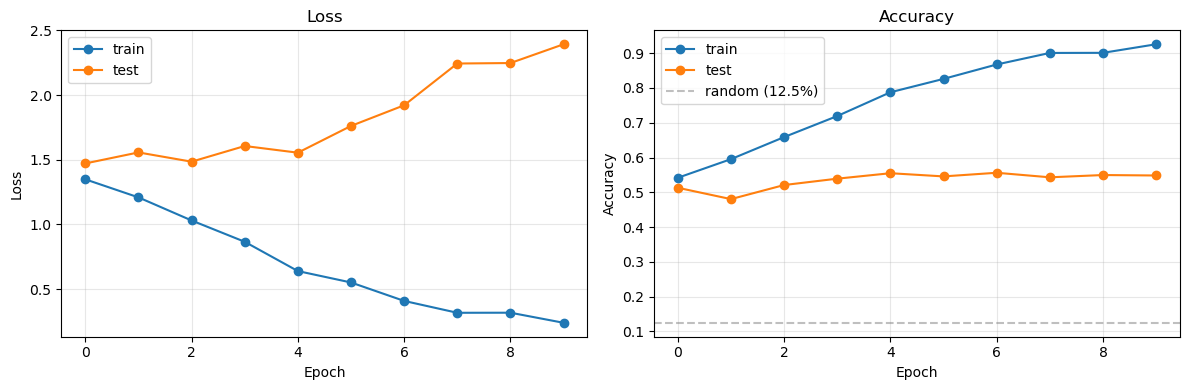

In [67]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history["train_loss"], label="train", marker="o")
axes[0].plot(history["test_loss"], label="test", marker="o")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history["train_acc"], label="train", marker="o")
axes[1].plot(history["test_acc"], label="test", marker="o")
axes[1].axhline(y=1/8, color="gray", linestyle="--", alpha=0.5, label="random (12.5%)")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
# New training transform with augmentation
train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),    # resize a bit larger first
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),  # then random crop to 128
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# test stays clean — no augmentation
test_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Rebuild datasets and loaders with the new transforms
train_ds = datasets.ImageFolder("my_heroes_split/train", transform=train_transform)
test_ds = datasets.ImageFolder("my_heroes_split/test", transform=test_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Augmented training pipeline ready.")

Augmented training pipeline ready.


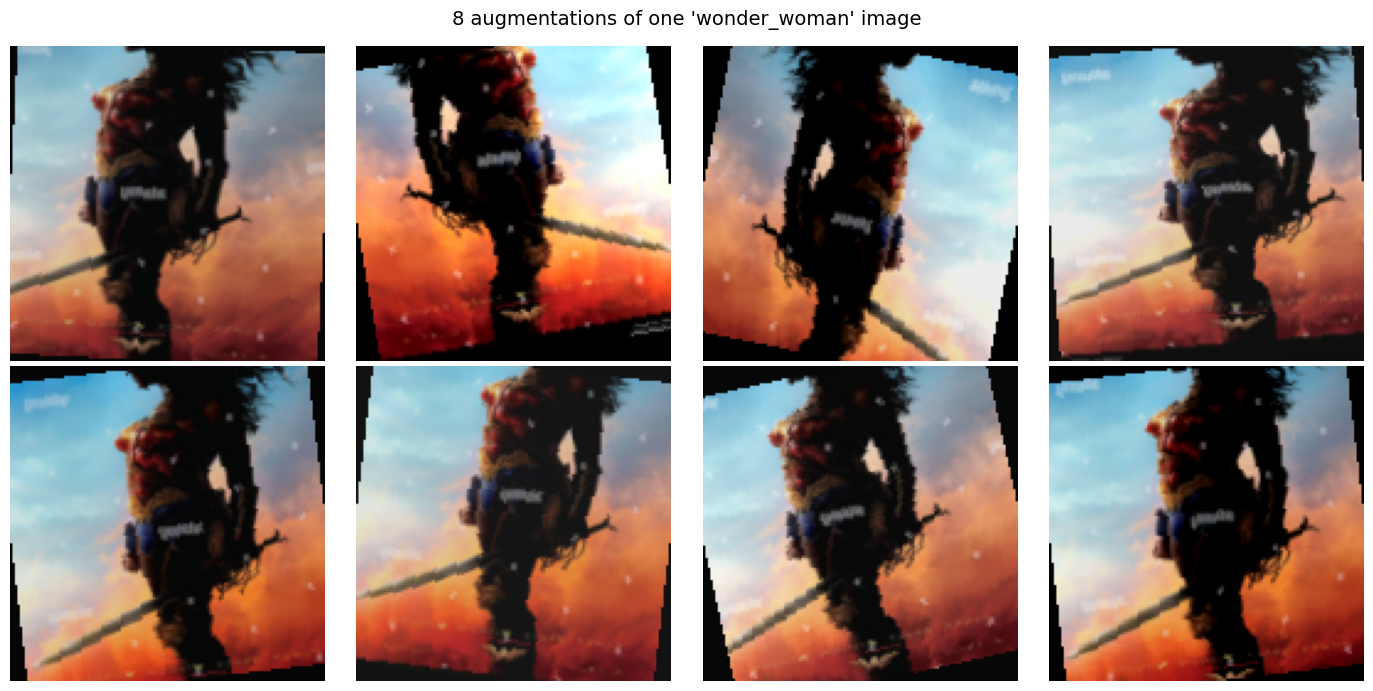

In [69]:
# Show 8 augmented versions of the SAME training image
import matplotlib.pyplot as plt
import numpy as np

# Get one image without augmentation for reference
raw_ds = datasets.ImageFolder("my_heroes_split/train")
raw_idx = random.randint(0, len(raw_ds) - 1)
raw_img, label = raw_ds[raw_idx]

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def denorm(t):
    img = t.numpy().transpose(1, 2, 0) * std + mean
    return np.clip(img, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax in axes.flatten():
    aug = train_transform(raw_img)
    ax.imshow(denorm(aug))
    ax.axis("off")
fig.suptitle(f"8 augmentations of one '{train_ds.classes[label]}' image", fontsize=14)
plt.tight_layout()
plt.show()

In [70]:
import copy

# 1. Fresh model, fresh optimizer
model = TinyCNN(num_classes=10).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

NUM_EPOCHS = 15
history_aug = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

best_acc = 0.0
best_weights = copy.deepcopy(model.state_dict())

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history_aug["train_loss"].append(train_loss)
    history_aug["train_acc"].append(train_acc)
    history_aug["test_loss"].append(test_loss)
    history_aug["test_acc"].append(test_acc)

    marker = ""
    if test_acc > best_acc:
        best_acc = test_acc
        best_weights = copy.deepcopy(model.state_dict())
        marker = "  ← new best"

    print(f"Epoch {epoch:2d} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"test loss {test_loss:.4f} acc {test_acc:.3f}{marker}")

print(f"\nBest test accuracy with augmentation: {best_acc:.3f}")
print(f"Previous (no augmentation):                 0.556")

model.load_state_dict(best_weights)

Epoch  1 | train loss 2.1764 acc 0.201 | test loss 1.9378 acc 0.275  ← new best


Epoch  2 | train loss 1.9212 acc 0.304 | test loss 1.8262 acc 0.347  ← new best


Epoch  3 | train loss 1.8660 acc 0.338 | test loss 1.7969 acc 0.349  ← new best


Epoch  4 | train loss 1.7470 acc 0.396 | test loss 1.8323 acc 0.376  ← new best


Epoch  5 | train loss 1.7042 acc 0.405 | test loss 1.6809 acc 0.430  ← new best


...

Epoch 12 | train loss 1.3523 acc 0.550 | test loss 1.4346 acc 0.516


Epoch 13 | train loss 1.3662 acc 0.531 | test loss 1.4529 acc 0.504


Epoch 14 | train loss 1.3586 acc 0.543 | test loss 1.5285 acc 0.499


Epoch 15 | train loss 1.3194 acc 0.569 | test loss 1.4212 acc 0.520

Best test accuracy with augmentation: 0.526
Previous (no augmentation):                 0.556


<All keys matched successfully>

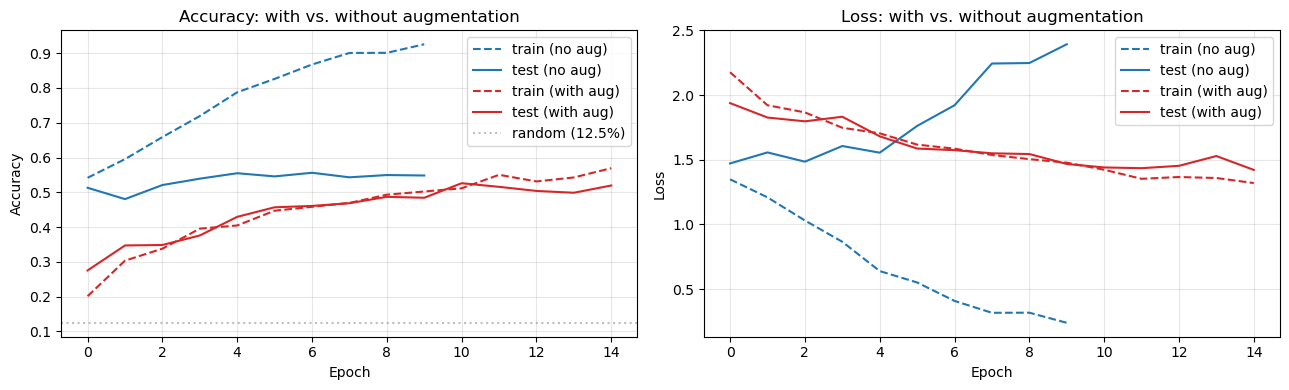

In [71]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_acc"],     label="train (no aug)",   color="#1f77b4", linestyle="--")
axes[0].plot(history["test_acc"],     label="test (no aug)",   color="#1f77b4")
axes[0].plot(history_aug["train_acc"], label="train (with aug)", color="#d62728", linestyle="--")
axes[0].plot(history_aug["test_acc"], label="test (with aug)", color="#d62728")
axes[0].axhline(y=1/8, color="gray", linestyle=":", alpha=0.5, label="random (12.5%)")
axes[0].set_title("Accuracy: with vs. without augmentation")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_loss"],     label="train (no aug)",   color="#1f77b4", linestyle="--")
axes[1].plot(history["test_loss"],     label="test (no aug)",   color="#1f77b4")
axes[1].plot(history_aug["train_loss"], label="train (with aug)", color="#d62728", linestyle="--")
axes[1].plot(history_aug["test_loss"], label="test (with aug)", color="#d62728")
axes[1].set_title("Loss: with vs. without augmentation")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [72]:
from torchvision import models

# 1. Bigger images — what ResNet expects
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

test_transform = transforms.Compose([
    transforms.Lambda(lambda img: img.convert("RGB")),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Smaller batch size — ResNet uses more GPU memory than TinyCNN
BATCH_SIZE = 32

train_ds = datasets.ImageFolder("my_heroes_split/train", transform=train_transform)
test_ds = datasets.ImageFolder("my_heroes_split/test", transform=test_transform)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 2. Load pretrained ResNet18
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# 3. Replace the final layer (originally 512 → 1000) with our own (512 → 10)
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 10)

resnet = resnet.to(device)

# 4. Use a LOWER learning rate — pretrained weights are precious, don't shake them too hard
optimizer = optim.AdamW(resnet.parameters(), lr=1e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

print("ResNet18 loaded with pretrained ImageNet weights.")
print(f"Total parameters: {sum(p.numel() for p in resnet.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in resnet.parameters() if p.requires_grad):,}")
print(f"Final layer: {resnet.fc}")

ResNet18 loaded with pretrained ImageNet weights.
Total parameters: 11,181,642
Trainable parameters: 11,181,642
Final layer: Linear(in_features=512, out_features=10, bias=True)


In [73]:
import copy

NUM_EPOCHS = 10
history_resnet = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

best_acc = 0.0
best_weights = copy.deepcopy(resnet.state_dict())

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(resnet, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(resnet, test_loader, criterion, device)

    history_resnet["train_loss"].append(train_loss)
    history_resnet["train_acc"].append(train_acc)
    history_resnet["test_loss"].append(test_loss)
    history_resnet["test_acc"].append(test_acc)

    marker = ""
    if test_acc > best_acc:
        best_acc = test_acc
        best_weights = copy.deepcopy(resnet.state_dict())
        marker = "  ← new best"

    print(f"Epoch {epoch:2d} | "
          f"train loss {train_loss:.4f} acc {train_acc:.3f} | "
          f"test loss {test_loss:.4f} acc {test_acc:.3f}{marker}")

print(f"\nResNet18 (pretrained):  best test acc = {best_acc:.3f}")
print(f"TinyCNN + augmentation: best test acc = 0.526")
print(f"TinyCNN no aug:         best test acc = 0.556")

resnet.load_state_dict(best_weights)

Epoch  1 | train loss 1.2143 acc 0.615 | test loss 0.6466 acc 0.811  ← new best


Epoch  2 | train loss 0.4909 acc 0.858 | test loss 0.5982 acc 0.805


Epoch  3 | train loss 0.2811 acc 0.927 | test loss 0.5208 acc 0.832  ← new best


Epoch  4 | train loss 0.1890 acc 0.950 | test loss 0.4224 acc 0.875  ← new best


Epoch  5 | train loss 0.1486 acc 0.966 | test loss 0.4424 acc 0.876  ← new best


...

Epoch  7 | train loss 0.0895 acc 0.977 | test loss 0.3808 acc 0.886  ← new best


Epoch  8 | train loss 0.0890 acc 0.978 | test loss 0.4284 acc 0.880


Epoch  9 | train loss 0.0667 acc 0.984 | test loss 0.3982 acc 0.894  ← new best


Epoch 10 | train loss 0.0626 acc 0.984 | test loss 0.3902 acc 0.890

ResNet18 (pretrained):  best test acc = 0.894
TinyCNN + augmentation: best test acc = 0.526
TinyCNN no aug:         best test acc = 0.556


<All keys matched successfully>

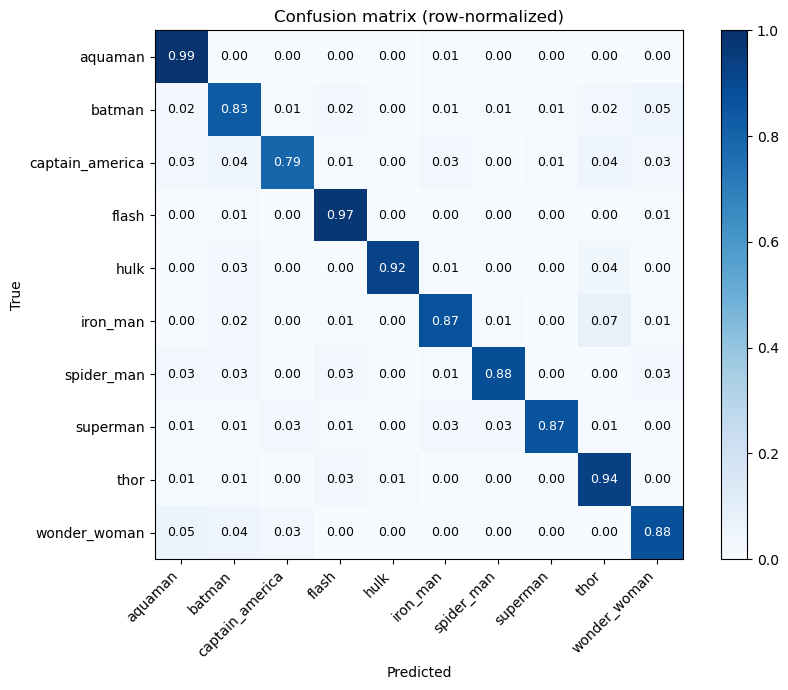


Per-class report:
                 precision    recall  f1-score   support

        aquaman      0.864     0.987     0.921        77
         batman      0.824     0.833     0.828        84
captain_america      0.915     0.794     0.850        68
          flash      0.880     0.971     0.923        68
           hulk      0.986     0.924     0.954        79
       iron_man      0.902     0.871     0.886        85
     spider_man      0.945     0.885     0.914        78
       superman      0.970     0.867     0.915        75
           thor      0.830     0.936     0.880        78
   wonder_woman      0.867     0.878     0.872        74

       accuracy                          0.894       766
      macro avg      0.898     0.895     0.894       766
   weighted avg      0.898     0.894     0.894       766



In [74]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

resnet.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = resnet(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
class_names = train_ds.classes

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalized

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm_normalized, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (row-normalized)")

# Cell labels
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, f"{cm_normalized[i, j]:.2f}",
                ha="center", va="center",
                color="white" if cm_normalized[i, j] > 0.5 else "black",
                fontsize=9)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print("\nPer-class report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

/opt/anaconda3/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Corrupt EXIF data.  Expecting to read 2 bytes but only got 0. 
  warnings.warn(str(msg))


Total mistakes: 81 / 766 (10.6%)


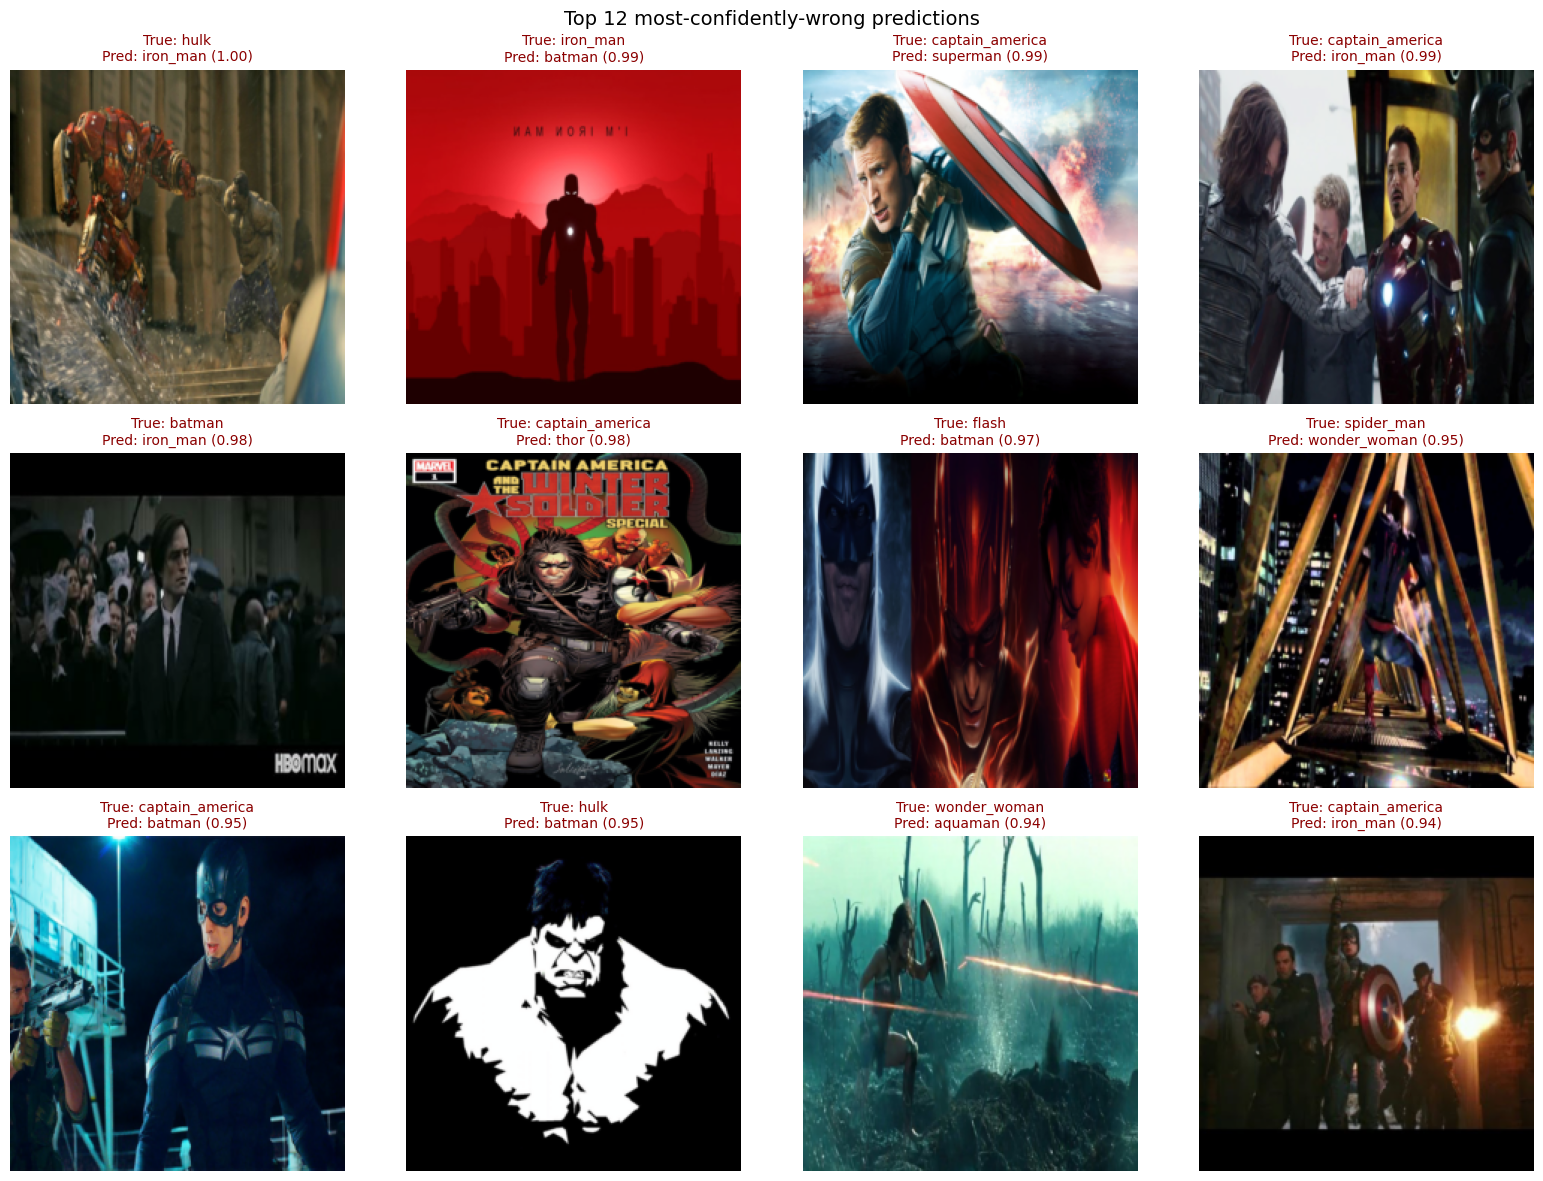

In [75]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

resnet.eval()

mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

def denorm(t):
    img = t.cpu().numpy().transpose(1, 2, 0) * std + mean
    return np.clip(img, 0, 1)

# Collect all misclassified examples
mistakes = []  # list of (image_tensor, true_label, pred_label, confidence)

with torch.no_grad():
    for images, labels in test_loader:
        images_dev = images.to(device)
        outputs = resnet(images_dev)
        probs = F.softmax(outputs, dim=1)              # convert logits → probabilities
        confs, preds = probs.max(dim=1)                # top class + its probability

        wrong_mask = preds.cpu() != labels
        for i in range(len(labels)):
            if wrong_mask[i]:
                mistakes.append((
                    images[i],
                    labels[i].item(),
                    preds[i].item(),
                    confs[i].item()
                ))

print(f"Total mistakes: {len(mistakes)} / {len(test_ds)} ({len(mistakes)/len(test_ds):.1%})")

# Sort by confidence — high-confidence wrongs are the most interesting
mistakes.sort(key=lambda x: -x[3])

class_names = train_ds.classes

# Show top 12 most-confidently-wrong predictions
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for ax, (img, true_lbl, pred_lbl, conf) in zip(axes.flatten(), mistakes[:12]):
    ax.imshow(denorm(img))
    ax.set_title(
        f"True: {class_names[true_lbl]}\n"
        f"Pred: {class_names[pred_lbl]} ({conf:.2f})",
        fontsize=10,
        color="darkred"
    )
    ax.axis("off")
fig.suptitle("Top 12 most-confidently-wrong predictions", fontsize=14)
plt.tight_layout()
plt.show()

In [76]:
import torch
import torch.nn.functional as F
import os
import shutil

resnet.eval()
class_names = train_ds.classes
test_dir = "my_heroes_split/test"

# We need image paths along with predictions, so loop manually instead of via DataLoader
suspects = []  # list of (path, true_label, pred_label, confidence)

with torch.no_grad():
    for true_idx, cls_name in enumerate(class_names):
        cls_dir = os.path.join(test_dir, cls_name)
        for fname in os.listdir(cls_dir):
            path = os.path.join(cls_dir, fname)
            try:
                img = Image.open(path).convert("RGB")
            except Exception:
                continue
            tensor = test_transform(img).unsqueeze(0).to(device)
            output = resnet(tensor)
            probs = F.softmax(output, dim=1)[0]
            conf, pred_idx = probs.max(dim=0)

            if pred_idx.item() != true_idx and conf.item() >= 0.70:
                suspects.append((path, true_idx, pred_idx.item(), conf.item()))

# Sort by confidence — review the most-confidently-wrong first
suspects.sort(key=lambda x: -x[3])

print(f"Found {len(suspects)} high-confidence wrong predictions in testation set")
print(f"(out of {len(test_ds)} total test images)")

Found 41 high-confidence wrong predictions in testation set
(out of 766 total test images)


In [77]:
torch.save(resnet.state_dict(), "resnet18_superhero.pth")
print("Model saved.")  

Model saved.
